# EDA

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

sys.path.append("..")

from src.data_pipeline.converter import convert_raw_to_markdown
from src.data_pipeline.chunker import split_markdown_documents

import warnings
warnings.filterwarnings('ignore')

In [ ]:
files = convert_raw_to_markdown()

chunks = split_markdown_documents(files)

chunk_lengths = [len(chunk.page_content) for chunk in chunks]

print(f"Всего чанков: {len(chunks)}")
print(f"Средняя длина чанка: {sum(chunk_lengths)/len(chunks):.0f} символов")

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

Всего чанков: 32
Средняя длина чанка: 548 символов


In [ ]:
chunk_data = []
for i, chunk in enumerate(chunks):
    chunk_data.append({
        "chunk_id": i,
        "source": chunk.metadata.get("source", "unknown"),
        "length_char": len(chunk.page_content),
        "length_words": len(chunk.page_content.split()),
        "section_level": "H3" if "header_3" in chunk.metadata 
                         else "H2" if "header_2" in chunk.metadata 
                         else "H1" if "header_1" in chunk.metadata 
                         else "Root"
    })

df = pd.DataFrame(chunk_data)

In [4]:
print(f"Всего оригинальных файлов: {len(files)}")
print(f"Всего созданных чанков: {len(chunks)}")

Всего оригинальных файлов: 5
Всего созданных чанков: 32


In [ ]:
print("Распределение длин чанков (в символах):")
display(df["length_char"].describe().to_frame().T)

print("\nКоличество чанков по документам-источникам:")
display(df["source"].value_counts().to_frame(name="Количество чанков"))

print("\nРаспределение чанков по уровню разделов:")
display(df["section_level"].value_counts().to_frame(name="Количество чанков"))

Распределение длин чанков (в символах):


,count,mean,std,min,25%,50%,75%,max
length_char,32.0,548.0625,279.819289,76.0,307.75,598.0,748.0,1032.0



Количество чанков по документам-источникам:


,Количество чанков
source,
NDA_2026.docx,10
employee_handbook.pdf,9
fire_safety.txt,6
vpn_setup_guide.md,5
equipment_limits.xlsx,2



Распределение чанков по уровню разделов:


,Количество чанков
section_level,
H2,28
Root,3
H1,1


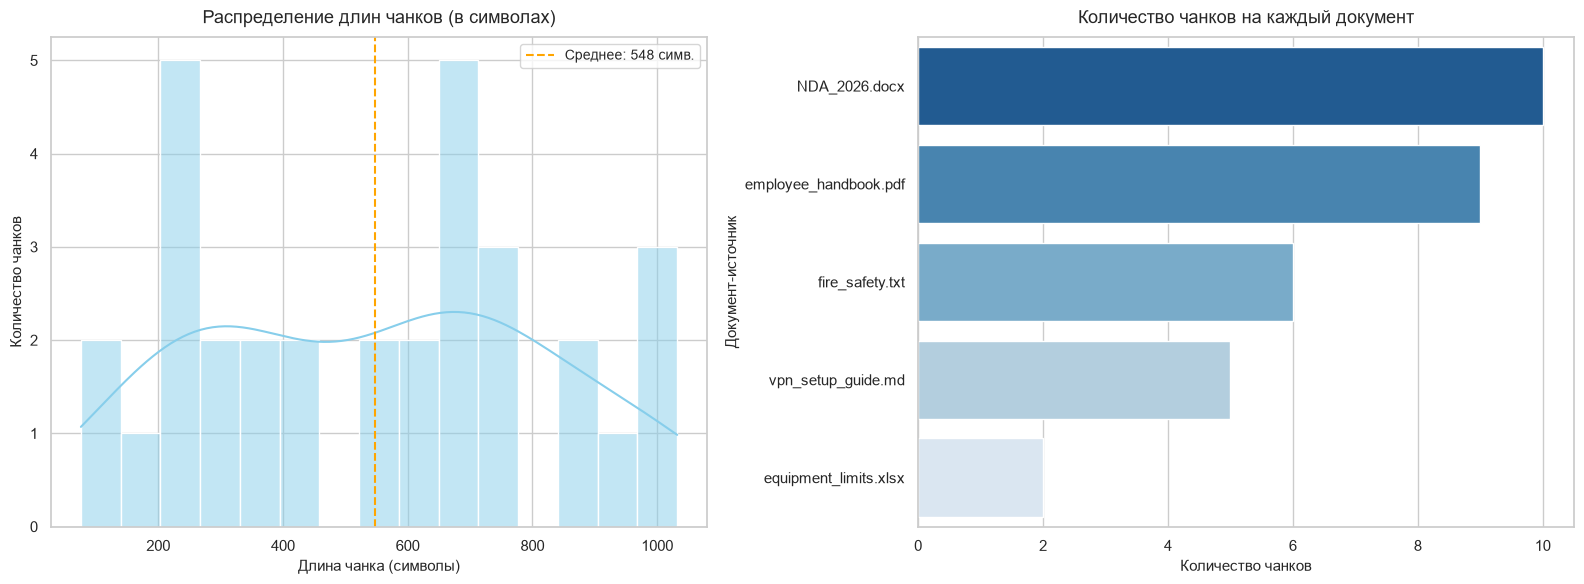

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["length_char"], bins=15, kde=True, color="skyblue", ax=axes[0])
mean_len = df["length_char"].mean()
axes[0].axvline(mean_len, color="orange", linestyle="--", linewidth=1.5, 
                label=f'Среднее: {mean_len:.0f} симв.')

axes[0].set_title("Распределение длин чанков (в символах)", fontsize=13, pad=10)
axes[0].set_xlabel("Длина чанка (символы)", fontsize=11)
axes[0].set_ylabel("Количество чанков", fontsize=11)
axes[0].legend(fontsize=10)

sns.countplot(
    data=df, 
    y="source", 
    palette="Blues_r", 
    order=df["source"].value_counts().index, 
    ax=axes[1]
)
axes[1].set_title("Количество чанков на каждый документ", fontsize=13, pad=10)
axes[1].set_xlabel("Количество чанков", fontsize=11)
axes[1].set_ylabel("Документ-источник", fontsize=11)

plt.tight_layout()

reports_dir = Path("../artifacts/figures")
reports_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(reports_dir / "eda_chunk_analysis.png", dpi=300)

plt.show()

In [ ]:
unique_sources = df["source"].unique()

display(Markdown("## Валидация содержимого чанков по источникам"))

for source in unique_sources:
    display(Markdown("---"))
    display(Markdown(f"### 📄 Источник: `{source}`"))

    source_chunks = [c for c in chunks if c.metadata.get("source") == source]

    for chunk in source_chunks:
    
        headers = [f"**{k}**: *{v}*" for k, v in chunk.metadata.items() if k != 'source']
        headers_str = "  |  ".join(headers) if headers else "*нет заголовков (плоский текст)*"
        display(Markdown(f"**Структура документа:** {headers_str}"))
        
        quoted_content = "\n".join([f"> {line}" for line in chunk.page_content.split("\n")])
        display(Markdown(quoted_content))

## Валидация содержимого чанков по источникам

---

### 📄 Источник: `employee_handbook.pdf`

**Структура документа:** *нет заголовков (плоский текст)*

> ООО «НейроСети»  
> Памятка сотрудника: отпуска, ДМС, график
> работы и бенефиты

...

> В случае утери файла конфигурации или блокировки учетной записи необходимо незамедлительно связаться с ИТ-отделом.

**Структура документа:** **header_1**: *Инструкция по настройке VPN и получению доступов в ООО «НейроСети»*  |  **header_2**: *2. Доступ к корпоративным сервисам*

> ## 2. Доступ к корпоративным сервисам  
> В ООО «НейроСети» действует единая система учетных записей (SSO) на базе корпоративной электронной почты. Сразу после успешного подключения к VPN вам становятся доступны следующие сервисы:
> * система контроля версий GitLab — адрес в сети `gitlab.neuro-networks.ru`, используется для хранения исходных кодов и весов моделей;
> * корпоративный мессенджер Mattermost — адрес в сети `chat.neuro-networks.ru`, является основным пространством для командного взаимодействия и оперативных созвонов;
> * облачное хранилище Nextcloud — адрес в сети `cloud.neuro-networks.ru`, используется для обмена документами и хранения обезличенных датасетов.

**Структура документа:** **header_1**: *Инструкция по настройке VPN и получению доступов в ООО «НейроСети»*  |  **header_2**: *3. Техническая поддержка и восстановление паролей*

> ## 3. Техническая поддержка и восстановление паролей  
> Если вы забыли пароль или столкнулись с технической ошибкой при авторизации, вы можете восстановить доступ следующими способами:
> * самостоятельно сбросить пароль через форму восстановления на странице SSO-авторизации;
> * создать обращение во внутренней системе технической поддержки Jira Service Desk;
> * отправить письмо с описанием проблемы и скриншотом ошибки на официальный адрес поддержки ИТ-департамента: `support@neuro-networks.ru`. Обращения в Jira Service Desk имеют высший приоритет и обрабатываются дежурными инженерами в течение 15 минут в рабочее время.